In [1]:
import pandas as pd
import numpy as np
import lal
import numpy.random as rng
import matplotlib.pyplot as plt

import time

from few.waveform import GenerateEMRIWaveform
from few.utils.utility import get_p_at_t
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux

from scipy.interpolate import CubicSpline
from few import get_file_manager

#from lsperi notebooks
import warnings

import h5py
from astropy.cosmology import Planck18 as COSMO
import astropy.units as u
from astropy.cosmology import z_at_value
from scipy.interpolate import CubicSpline

from few.trajectory.ode.flux import KerrEccEqFlux, get_separatrix

/var/folders/p3/zq_xf6g554d28rrxhsngpp_00000gr/T/ipykernel_22132/4150062095.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [7]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

In [8]:
#from lsperi notebooks
warnings.filterwarnings("ignore")
EPS = 1e-2
MODES = [(ll, mm, nn) for ll in range(2, 5) for mm in range(1, ll + 1) for nn in range(-1, 3)]

DEFAULT_ANGLES = {
    "qS": np.pi / 3,
    "phiS": np.pi / 3,
    "qK": np.pi / 3,
    "phiK": np.pi / 3,
    "Phi_phi0": np.pi / 3,
    "Phi_theta0": 0.0,
    "Phi_r0": np.pi / 3,
}

global FEW_GEN, TRAJ, RHS

TRAJ = EMRIInspiral(func=KerrEccEqFlux)
RHS = KerrEccEqFlux()
FEW_GEN = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, output_type="fd", odd_len=True),
    return_list=True,
)

In [9]:
# produce sensitivity function
traj_module = EMRIInspiral(func=KerrEccEqFlux)

# import ASD
data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
data[:, 1] = data[:, 1] ** 2
# define PSD function
get_sensitivity = CubicSpline(*data.T)

# define inner product [eq 3 of https://www.nature.com/articles/s41550-022-01849-y]
def inner_product(x, y, psd):
    return 4 * np.real(np.sum(np.conj(x) * y / psd))

def SNR_calc(m1, m2, a, e0, x0, dist, Tobs, dt, mode_selection_threshold, printing=True):
    truestart = time.time()

    #to be randomised
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = dist      # luminosity distance (Gpc)
    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }
    start = time.time()

    # get the initial p0 required for an inspiral of length Tobs, given the fixed values of the other parameters
    p0 = get_p_at_t(
        traj_module,
        Tobs * 0.999,
        [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
        index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called
        index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
        index_of_e=4,               # etc...
        index_of_x=5,
        traj_kwargs={},
        xtol=2e-12,                 # absolute tolerance for the brentq root finder
        rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
        bounds=None,
    )
    # print("New p0: ", p0)
    end = time.time()
    # print("Time taken to find p0: ", end - start, "seconds")
    p0_time=end - start

    emri_injection_params = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,]

    # generate the TD signal, and time how long it takes
    start = time.time()
    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) # Returns 2 arrays containing the plus and cross polarizations
    end = time.time()
    # print("Time taken to generate the TD signal: ", end - start, "seconds")
    td_time=end - start

    start = time.time()
    # take the FFT of the plus polarization and shift it
    fft_TD = np.fft.fftshift(np.fft.fft(data_channels_td[0])) * dt
    freq = np.fft.fftshift(np.fft.fftfreq(len(data_channels_td[0]), dt))

    # define the positive frequencies
    positive_frequency_mask = freq >= 0.0

    # calculate the mismatch between the FFT'd TD waveform and the direct FD waveform:
    psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]
    td_td = inner_product(fft_TD[positive_frequency_mask], fft_TD[positive_frequency_mask], psd)

    end = time.time()
    total_time=end - truestart
    snr_time=end - start

    snr=np.sqrt(td_td)

    # print("Time taken to calculate the SNR: ", end - start, "seconds")
    if printing==True:
        print(f"Total time taken: {total_time} s\np0: {p0_time} s, td: {td_time} s, snr: {snr_time} s")
        print("TD SNR:", snr)
    return snr, [total_time, p0_time, td_time, snr_time]


#from lsperi notebooks
def redshift_to_luminosity_distance(z):
    return COSMO.luminosity_distance(z).value * 1e-3  # Gpc

def get_spline_psd(filename="LISA v1.0_PSD.h5"):
    with h5py.File(filename, "r") as data:
        key = filename.split("_PSD.h5")[0]
        psd_data = data[key]["sensitivities_links"][()]
        f_psd = data[key]["f"][()]
    return CubicSpline(f_psd, psd_data)


def get_spline_psd_alice(filename):
    f_psd, asd_psd = np.loadtxt(filename, unpack=True)
    return CubicSpline(f_psd, asd_psd ** 2)


def get_psd_wrapper(psd="LISA"):
    if psd == "LISA":
        f_psd, asd_psd = np.loadtxt("PSD_plus_foregrounds_LISA_LS_asd.dat", unpack=True)
        cubic_spline_psd = CubicSpline(f_psd, asd_psd**2)
        # print(f"Using PSD from PSD_plus_foregrounds_LISA_LS_asd.dat...", cubic_spline_psd)
        fmin, fmax = 1e-4, 1.0
    elif psd == "AMADEUS":
        f_psd, asd_psd = np.loadtxt("PSD_plus_foreground_AMADEUS-Baseline_asd.txt", unpack=True)
        cubic_spline_psd = CubicSpline(f_psd, asd_psd**2)
        # print(f"Using PSD from PSD_plus_foreground_AMADEUS-Baseline_asd.txt...", cubic_spline_psd)
        fmin, fmax = 1e-6, 1.0
    elif psd == "DO-IT":
        f_psd, asd_psd = np.loadtxt("PSD_plus_foreground_DO-IT-Baseline_asd.txt", unpack=True)
        cubic_spline_psd = CubicSpline(f_psd, asd_psd**2)
        # print(f"Using PSD from PSD_plus_foreground_DO-IT-Baseline_asd.txt...", cubic_spline_psd)
        fmin, fmax = 1e-4, 10.0
    #my addition
    elif psd == 'LISA_FEW':
        data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
        data[:, 1] = data[:, 1] ** 2
        # define PSD function
        cubic_spline_psd = CubicSpline(*data.T)
        fmin, fmax = 1e-4, 1.0
    return cubic_spline_psd, fmin, fmax


def get_initial_conditions(params, err=1e-6):
    m1, m2, a, Tpl, ef = params
    x0 = 1.0
    RHS.add_fixed_parameters(m1, m2, a)

    p_0 = TRAJ.inspiral_generator.func.separatrix_buffer_dist + get_separatrix(a, ef, x0) + 1e-3
    forward_result = TRAJ(m1, m2, a, p_0, ef, x0, T=10.0, integrate_backwards=False, err=err)
    backwards_result = TRAJ(
        m1,
        m2,
        a,
        forward_result[1][-1],
        forward_result[2][-1],
        x0,
        T=Tpl,
        integrate_backwards=True,
        err=err,
    )

    p0 = backwards_result[1][-1]
    e0 = backwards_result[2][-1]
    x0 = backwards_result[3][-1]

    f_phi_theta_r = TRAJ.inspiral_generator.eval_integrator_derivative_spline(backwards_result[0], order=1)
    f_phi = -f_phi_theta_r[:, 3] / (2 * np.pi)
    f_r = -f_phi_theta_r[:, 5] / (2 * np.pi)
    return p0, e0, x0, f_phi, f_r

def compute_snr(
    m1,
    m2,
    a,
    Tobs,
    ef,
    z,
    dt,
    qS=None,
    phiS=None,
    qK=None,
    phiK=None,
    Phi_phi0=None,
    Phi_theta0=None,
    Phi_r0=None,
    psd="LISA",
    num_freq=5000,
):

    qS = DEFAULT_ANGLES["qS"] if qS is None else qS
    phiS = DEFAULT_ANGLES["phiS"] if phiS is None else phiS
    qK = DEFAULT_ANGLES["qK"] if qK is None else qK
    phiK = DEFAULT_ANGLES["phiK"] if phiK is None else phiK
    Phi_phi0 = DEFAULT_ANGLES["Phi_phi0"] if Phi_phi0 is None else Phi_phi0
    Phi_theta0 = DEFAULT_ANGLES["Phi_theta0"] if Phi_theta0 is None else Phi_theta0
    Phi_r0 = DEFAULT_ANGLES["Phi_r0"] if Phi_r0 is None else Phi_r0

    dist = redshift_to_luminosity_distance(z)
    try:
        p0, e0, x0, _, _ = get_initial_conditions(np.asarray([m1 * (1 + z), m2 * (1 + z), a, Tobs, ef]))
    except Exception as exc:
        print(f"Error computing initial conditions for m1={m1}, m2={m2}, a={a}, Tobs={Tobs}, ef={ef}, z={z}: {exc}")
        return 0.0

    cubic_spline_psd, fmin, fmax = get_psd_wrapper(psd)
    f_pos = np.linspace(fmin, fmax, num=num_freq)
    freq = np.hstack((-f_pos[::-1], np.asarray([0.0]), f_pos))

    hf = FEW_GEN(
        m1 * (1 + z),
        m2 * (1 + z),
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
        T=Tobs,
        dt=dt,
        f_arr=freq,
        mask_positive=True,
        mode_selection=MODES,
    )

    h_plus = np.asarray(hf[0])[1:]
    h_cross = np.asarray(hf[1])[1:]
    df = f_pos[1] - f_pos[0]
    snr_squared = 4.0 * np.sum((np.abs(h_plus) ** 2 + np.abs(h_cross) ** 2) / cubic_spline_psd(f_pos) * df)
    return float(np.sqrt(snr_squared))

In [10]:
BIMF='Bartos'
BH='1.0e+06'
DT="SG"
a=0.1
spin=0.9
tdisk=10.0
wind='Partial'
TT='P10'
N=6311

filename=f'EMRI_Rates/{BIMF}/MBH_{BH}/{DT}/alpha_{a}/spin_{spin}/Tdisk_{tdisk}/wind_{wind}/EMRIs_{TT}_1g_{N}.txt'

with open(filename) as f:
    lines = f.readlines()

header_end = lines.index("Data:\n") + 1

for i in range (4, header_end-2):
    print(f'{lines[i].split(" = ")[0]}={lines[i].split(" = ")[1]}')

alpha=lines[6].split("= ",1)[1]
alpha=alpha.split('\n')[0]
print(float(alpha))

Mbh=lines[9].split("= ",1)[1]
Mbh=float(Mbh.split('\n')[0])
print(Mbh)

data = pd.read_csv(filename, delimiter=" ", skiprows=header_end)

data.columns = [col.strip().replace(",", "") for col in data.columns]
print(data.keys())

N=len(data["m1/Msun"])
print(f'Columns: {header_end}, Rows: {N}')

m1=data['m1/Msun']
print(m1[0])

disk_type=SG

torque_type=P10

alpha=0.1

gen=1g

N=6311

M_SMBH=1000000.0

Spin=0.9

T=10.0

0.1
1000000.0
Index(['m1/Msun', 'r0/Rg', 'cos_i', 't_align/Myr', 't_gw/Myr', 't_migr/Myr',
       't_inspiral/Myr', 'Ng', 'R_final/Rg', 'lisa_radii/Rg', 't_lisa/Myr',
       't_final/Myr', 'lisa_flag', 'total_flags'],
      dtype='object')
Columns: 14, Rows: 81
7.262


In [11]:
Tobs = 4  # observation time (years), if the inspiral is shorter, the it will be zero padded
dt = 5.0    # time interval (seconds)
mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
            # the total power above this threshold will be included in the waveform.
x0 = 1.0 #initial cos(inclination) - fine to assume as 1 due to short timescale of alignment compared to inspiral
e0 = 0  # eccentricity - assumed circular in runs anyway
m1 = Mbh # central object mass (solar masses)
a = spin   # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform

SNR_time=[]
SNRs_20s=[]

for i in range(0, N):
    truestart = time.time()
    # define the injection parameters
    m2 = data['m1/Msun'][i]  # secondary object mass (solar masses)
    # p0 = 2*data['r0/Rg'][i]  # initial dimensionless semi-latus rectum
    dist=1

    print(f'\ni:{i}, m2: {m2} Msun')
    snr, timings=SNR_calc(m1, m2, a, e0, x0, dist, Tobs, dt, mode_selection_threshold, printing=True)
    
    SNR_time.append(timings[0])
    SNRs_20s.append(snr)

mean=np.mean(SNR_time)
sd=np.std(SNR_time)

print(SNRs_20s)

print(f"Avg. time: {mean}±{sd} s")


i:0, m2: 7.262 Msun
Total time taken: 24.630703926086426 s
p0: 0.5587921142578125 s, td: 17.472500801086426 s, snr: 6.5993971824646 s
TD SNR: 89.50426451682188

i:1, m2: 17.29 Msun
Total time taken: 12.27646017074585 s
p0: 0.5726759433746338 s, td: 4.767054796218872 s, snr: 6.936713933944702 s
TD SNR: 145.19848140871164

i:2, m2: 7.04 Msun
Total time taken: 10.572211027145386 s
p0: 0.5264766216278076 s, td: 3.5815911293029785 s, snr: 6.4641358852386475 s
TD SNR: 87.88967826968141

i:3, m2: 10.01 Msun
Total time taken: 11.394201040267944 s
p0: 0.5772051811218262 s, td: 3.6075639724731445 s, snr: 7.209423065185547 s
TD SNR: 107.59122700922859

i:4, m2: 7.96 Msun
Total time taken: 13.030048131942749 s
p0: 0.5342159271240234 s, td: 3.6066040992736816 s, snr: 8.889210939407349 s
TD SNR: 94.41143618825163

i:5, m2: 5.241 Msun
Total time taken: 13.16283917427063 s
p0: 0.4554262161254883 s, td: 3.8975961208343506 s, snr: 8.809794187545776 s
TD SNR: 73.624304329474

i:6, m2: 32.07 Msun
Total t

In [12]:
print(SNRs_20s)

[89.50426451682188, 145.19848140871164, 87.88967826968141, 107.59122700922859, 94.41143618825163, 73.624304329474, 201.04590807474864, 86.19462090518192, 77.02790171561641, 82.11644837412278, 73.624304329474, 144.2950100008139, 92.92599800208477, 110.04432812501706, 97.424244481955, 78.78155712173424, 134.05488936953995, 82.11644837412278, 145.19848140871164, 87.88967826968141, 72.4612616679899, 83.24201218183026, 140.06415630424496, 101.14983237480871, 114.05669941033948, 103.27919180803889, 96.40752534704102, 81.62296952175653, 202.8597352097542, 202.8597352097542, 85.82785899823124, 156.68141858504342, 108.49497155723263, 91.1983571999874, 156.68141858504342, 87.29360193172114, 82.48281947808282, 95.93587109772098, 199.9037599946754, 75.63408060275783, 72.4612616679899, 73.03615097044307, 141.13365151026306, 152.62105100706142, 76.92849415241122, 89.96471925508776, 83.05668971649635, 103.07128088684495, 84.83262220517514, 89.87854983100611, 172.15895805351056, 96.40752534704102, 110

In [13]:
dts=5.0, 10.0, 25.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0
SNRs_diff=[]
SNRs_sds=[]
time_p0=[]
time_TD=[]
time_SNR=[]
time_total=[]

In [14]:
for dt in dts:
    print(f'dt: {dt} s')
    Tobs = 4  # observation time (years), if the inspiral is shorter, the it will be zero padded
    dt = dt    # time interval (seconds)
    mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
                # the total power above this threshold will be included in the waveform.
    x0 = 1.0 #initial cos(inclination) - fine to assume as 1 due to short timescale of alignment compared to inspiral
    e0 = 0  # eccentricity - assumed circular in runs anyway
    m1 = Mbh # central object mass (solar masses)
    a = spin   # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform

    SNR_time=[]
    total_time=[]
    TD_time=[]
    p0_time=[]
    SNRs=[]

    for i in range(0, N):
        # define the injection parameters
        m2 = data['m1/Msun'][i]  # secondary object mass (solar masses)
        # p0 = 2*data['r0/Rg'][i]  # initial dimensionless semi-latus rectum

        print(f'\ni:{i}, m2: {m2} Msun')

        SNR, timings=SNR_calc(m1, m2, a, e0, x0, dist, Tobs, dt, mode_selection_threshold, printing=True)

        SNRs.append(SNR)
        p0_time.append(timings[1])
        TD_time.append(timings[2])
        SNR_time.append(timings[3])
        total_time.append(timings[0])

    mean=np.mean(total_time)
    sd=np.std(total_time)

    print(f"Avg. time: {mean}±{sd} s")

    dif=np.array(SNRs_20s)-np.array(SNRs)

    SNRs_diff.append(np.mean(dif))
    SNRs_sds.append(np.std(dif))
    time_p0.append(np.mean(p0_time))
    time_TD.append(np.mean(TD_time))
    time_SNR.append(np.mean(SNR_time))
    time_total.append(np.mean(total_time))


dt: 5.0 s

i:0, m2: 7.262 Msun
Total time taken: 9.59486699104309 s
p0: 0.5429329872131348 s, td: 3.657608985900879 s, snr: 5.394311904907227 s
TD SNR: 89.50426451682188

i:1, m2: 17.29 Msun
Total time taken: 10.637226104736328 s
p0: 0.5715930461883545 s, td: 3.6808700561523438 s, snr: 6.384757995605469 s
TD SNR: 145.19848140871164

i:2, m2: 7.04 Msun
Total time taken: 9.388253211975098 s
p0: 0.522036075592041 s, td: 3.575587034225464 s, snr: 5.290623903274536 s
TD SNR: 87.88967826968141

i:3, m2: 10.01 Msun
Total time taken: 9.299909830093384 s
p0: 0.5541732311248779 s, td: 3.596564292907715 s, snr: 5.149167060852051 s
TD SNR: 107.59122700922859

i:4, m2: 7.96 Msun
Total time taken: 9.970298051834106 s
p0: 0.528090238571167 s, td: 3.6015639305114746 s, snr: 5.840640068054199 s
TD SNR: 94.41143618825163

i:5, m2: 5.241 Msun
Total time taken: 9.658594846725464 s
p0: 0.44510531425476074 s, td: 3.679764986038208 s, snr: 5.533719778060913 s
TD SNR: 73.624304329474

i:6, m2: 32.07 Msun
Tota

In [15]:
SNRs_difference=[]

for i in range(0, len(SNRs_diff)):
    print(np.mean(SNRs_diff[i]))
    SNRs_difference.append(np.sqrt(np.mean(SNRs_diff[i])**2))

print(SNRs_diff)


0.0
1.534842559163471e-05
2.5621419433964605e-05
-2.0934017298674727e-06
-0.04670269759466858
0.20933094794663987
2.8528887396162315
7.378282505457838
12.913280093922719
19.09781671223887
[0.0, 1.534842559163471e-05, 2.5621419433964605e-05, -2.0934017298674727e-06, -0.04670269759466858, 0.20933094794663987, 2.8528887396162315, 7.378282505457838, 12.913280093922719, 19.09781671223887]


[9.744327236104894, 5.104470417823321, 2.0851874380935858, 2.3757515777776272, 1.8982080206458951, 1.6737439632415771, 1.5551125473446317, 1.4585652439682573, 1.377153464305548, 1.3272927925910478]


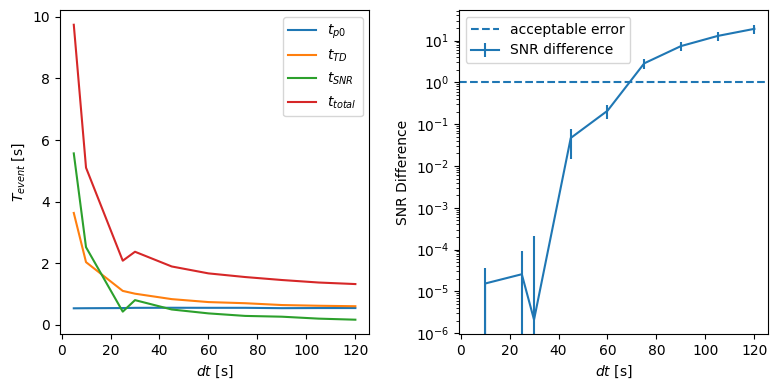

In [19]:

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(8, 4))
print(time_total)

ax.plot(dts, time_p0 , label='$t_{p0}$')
ax.plot(dts, time_TD ,label='$t_{TD}$')
ax.plot(dts, time_SNR ,label='$t_{SNR}$')
ax.plot(dts, time_total ,label='$t_{total}$')
# plt.xlim(0,60)
# plt.ylim(1e-6, 11)
ax.set_xlabel('$dt$ [s]')
ax.set_ylabel('$T_{event}$ [s]')
ax.legend()

ax2.errorbar(dts, SNRs_difference, yerr=SNRs_sds, label='SNR difference')
ax2.set_xlabel('$dt$ [s]')
ax2.set_ylabel('SNR Difference')
ax2.set_yscale('log')
ax2.axhline(y=1.0, linestyle='--', label='acceptable error')
ax2.legend()
fig.tight_layout()

fig.savefig(f'/Users/pmxks13/PhD/EMRIs_test/EMRI_Rates/SNR_testing.png')
fig.show()


In [ ]:
Tobs = 4  # observation time (years), if the inspiral is shorter, the it will be zero padded
dt = 5    # time interval (seconds)
mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
            # the total power above this threshold will be included in the waveform.
x0 = 1.0 #initial cos(inclination) - fine to assume as 1 due to short timescale of alignment compared to inspiral
e0 = 0  # eccentricity - assumed circular in runs anyway
m1 = Mbh # central object mass (solar masses)
a = spin   # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform

Speri_time=[]

for i in range(0, N):
    # define the injection parameters
    m2 = data['m1/Msun'][i] # secondary object mass (solar masses)
    # p0 = 2*data['r0/Rg'][i]  # initial dimensionless semi-latus rectum
    start = time.time()

    dist = 1.0
    ef = 0.0
    z = z_at_value(COSMO.luminosity_distance, dist * u.Gpc)

    SNR=compute_snr( m1 ,m2,a, Tobs, ef, z, dt, psd='LISA')
    end = time.time()
    Speri_time.append(end-start)
    print(f'\ni:{i}, m2: {m2} Msun, SNR: {SNR}, SNR_diff: {SNR-SNRs_20s[i]}')

mean=np.mean(Speri_time)
sd=np.std(Speri_time)
print(f"Avg. Speri time: {mean}±{sd} s")

mean=np.mean(SNR_time)
sd=np.std(SNR_time)
print(f"Avg. my time: {mean}±{sd} s")


i:0, m2: 7.262 Msun, SNR: 95.19275371193308, SNR_diff: 5.688489195111202

i:1, m2: 17.29 Msun, SNR: 141.26683854919457, SNR_diff: -3.931642859517069

i:2, m2: 7.04 Msun, SNR: 83.24301990777109, SNR_diff: -4.646658361910326

i:3, m2: 10.01 Msun, SNR: 92.29238962676854, SNR_diff: -15.29883738246005

i:4, m2: 7.96 Msun, SNR: 91.14649406647423, SNR_diff: -3.264942121777395

i:5, m2: 5.241 Msun, SNR: 75.8604397884573, SNR_diff: 2.2361354589832985

i:6, m2: 32.07 Msun, SNR: 187.86983139668502, SNR_diff: -13.176076678063623

i:7, m2: 6.811 Msun, SNR: 87.68868216516124, SNR_diff: 1.4940612599793184

i:8, m2: 5.644 Msun, SNR: 80.73514248299718, SNR_diff: 3.7072407673807675

i:9, m2: 6.277 Msun, SNR: 79.71345469391605, SNR_diff: -2.402993680206734

i:10, m2: 5.241 Msun, SNR: 75.8604397884573, SNR_diff: 2.2361354589832985

i:11, m2: 17.09 Msun, SNR: 138.1895294105358, SNR_diff: -6.105480590278091

i:12, m2: 7.745 Msun, SNR: 91.45666431054535, SNR_diff: -1.4693336915394184

i:13, m2: 10.42 Msun, 

In [91]:
dts_speri=0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0

SNRs_diff_Speri=[]
SNRs_sds_Speri=[]
time_total_Speri=[]

for dt in dts_speri:
    print(f'dt: {dt} s')
    Tobs = 4  # observation time (years), if the inspiral is shorter, the it will be zero padded
    dt = dt    # time interval (seconds)
    mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
                # the total power above this threshold will be included in the waveform.
    x0 = 1.0 #initial cos(inclination) - fine to assume as 1 due to short timescale of alignment compared to inspiral
    e0 = 0  # eccentricity - assumed circular in runs anyway
    m1 = Mbh # central object mass (solar masses)
    a = spin   # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform

    total_Speri_time=[]
    SNRs_Speri=[]

    for i in range(0, N):
        m2 = data['m1/Msun'][i] # secondary object mass (solar masses)
        # p0 = 2*data['r0/Rg'][i]  # initial dimensionless semi-latus rectum
        start = time.time()
        dist = 1.0
        ef = 0.0
        z = z_at_value(COSMO.luminosity_distance, dist * u.Gpc)

        SNR=compute_snr( m1 ,m2,a, Tobs, ef, z, dt, psd='LISA')
        end = time.time()
        total_Speri_time.append(end-start)
        SNRs_Speri.append(SNR)
        # SNRs_diff_Speri.append(SNR-SNRs_20s[i])
        print(f'\ni:{i}, m2: {m2} Msun, SNR: {SNR}, SNR_diff: {SNR-SNRs_20s[i]}')

    mean=np.mean(total_Speri_time)
    sd=np.std(total_Speri_time)

    print(f"Avg. time: {mean}±{sd} s")

    dif=np.array(SNRs_20s)-np.array(SNRs_Speri)

    SNRs_diff_Speri.append(np.mean(dif))
    SNRs_sds_Speri.append(np.std(dif))
    time_total_Speri.append(np.mean(total_Speri_time))


dt: 0.5 s

i:0, m2: 7.262 Msun, SNR: 111.17342609105725, SNR_diff: 21.669161574235375

i:1, m2: 17.29 Msun, SNR: 168.02247635634365, SNR_diff: 22.823994947632002

i:2, m2: 7.04 Msun, SNR: 100.23629616888553, SNR_diff: 12.34661789920412

i:3, m2: 10.01 Msun, SNR: 113.47930014094285, SNR_diff: 5.888073131714265

i:4, m2: 7.96 Msun, SNR: 109.21577031316104, SNR_diff: 14.804334124909417

i:5, m2: 5.241 Msun, SNR: 90.54269323522573, SNR_diff: 16.918388905751726

i:6, m2: 32.07 Msun, SNR: 224.45478453661065, SNR_diff: 23.408876461862008

i:7, m2: 6.811 Msun, SNR: 104.40946606609988, SNR_diff: 18.21484516091796

i:8, m2: 5.644 Msun, SNR: 95.9422104044566, SNR_diff: 18.914308688840194

i:9, m2: 6.277 Msun, SNR: 95.56143779317793, SNR_diff: 13.444989419055148

i:10, m2: 5.241 Msun, SNR: 90.54269323522573, SNR_diff: 16.918388905751726

i:11, m2: 17.09 Msun, SNR: 163.98484174040462, SNR_diff: 19.689831739590716

i:12, m2: 7.745 Msun, SNR: 108.5714576146868, SNR_diff: 15.645459612602039

i:13, m2:

In [92]:
for i in range(0, len(dts_speri)):
    print(f'dt: {dts_speri[i]}, SNR diff: {SNRs_diff_Speri[i]}±{SNRs_sds_Speri[i]}')

dt: 0.5, SNR diff: -19.10530116750836±5.89250741565971
dt: 1.0, SNR diff: -37.434256158672085±7.940137617108321
dt: 1.5, SNR diff: -24.736998692302805±6.546879846183015
dt: 2.0, SNR diff: 14.219774985585886±8.187820867578123
dt: 2.5, SNR diff: 55.72712734810823±19.421139892241573
dt: 3.0, SNR diff: 36.723565292972296±13.942463964954639
dt: 3.5, SNR diff: -8.9680989765536±5.282415090450564
dt: 4.0, SNR diff: -35.20008354011047±7.808443111429175
dt: 4.5, SNR diff: -31.346964347305075±7.382117486209906
dt: 5.0, SNR diff: 1.2177910501413645±5.884807180445036
dt: 5.5, SNR diff: 47.12450867179993±16.902740272575926
dt: 6.0, SNR diff: 48.556960234912246±17.318406591434798
dt: 6.5, SNR diff: 2.913183744388293±6.105084454631958
dt: 7.0, SNR diff: -30.585178202876104±7.288573923903379
dt: 7.5, SNR diff: -35.64329309397538±7.8482613009307425
dt: 8.0, SNR diff: -10.451280167156405±5.304544538876373
dt: 8.5, SNR diff: 34.95662929408584±13.451975970245373
dt: 9.0, SNR diff: 56.467930837253135±19.640

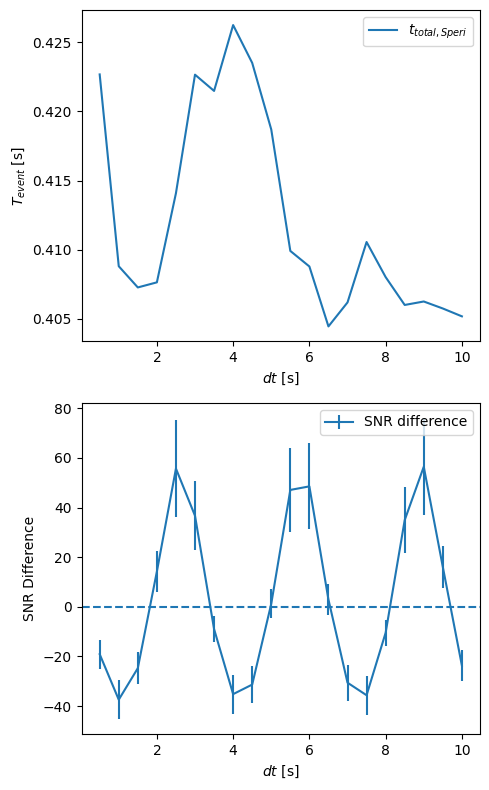

In [94]:
dts=5.0, 10.0, 25.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(5, 8))

ax.plot(dts_speri, time_total_Speri ,label='$t_{total,Speri}$')
# ax.plot(dts, SNR_time, label='$t_{total}$')
# plt.xlim(0,60)
# plt.ylim(1e-6, 11)
ax.set_xlabel('$dt$ [s]')
ax.set_ylabel('$T_{event}$ [s]')
ax.legend()

ax2.errorbar(dts_speri, SNRs_diff_Speri, yerr=SNRs_sds_Speri, label='SNR difference')
ax2.set_xlabel('$dt$ [s]')
ax2.set_ylabel('SNR Difference')
# ax2.set_yscale('log')
ax2.axhline(y=0.0, linestyle='--')
ax2.legend()
fig.tight_layout()

fig.savefig(f'/Users/pmxks13/PhD/EMRIs_test/EMRI_Rates/{BIMF}/MBH_{BH}/{DT}/alpha_0.1/spin_{spin}/Tdisk_{tdisk}/wind_{wind}/SNR_Speri_4.png')
fig.show()

In [114]:
m2=data['m1/Msun']
flag=data['lisa_flag']

for i in range(0, len(SNRs_20s)):
    print(f'{i}: {m2[i]:.1f} Msun, SNR: {SNRs_20s[i]:.1f}, flag {flag[i]}')

0: 7.3 Msun, SNR: 89.5, flag 4
1: 17.3 Msun, SNR: 145.2, flag 4
2: 7.0 Msun, SNR: 87.9, flag 4
3: 10.0 Msun, SNR: 107.6, flag 4
4: 8.0 Msun, SNR: 94.4, flag 4
5: 5.2 Msun, SNR: 73.6, flag 4
6: 32.1 Msun, SNR: 201.0, flag 0
7: 6.8 Msun, SNR: 86.2, flag 4
8: 5.6 Msun, SNR: 77.0, flag 4
9: 6.3 Msun, SNR: 82.1, flag 4
10: 5.2 Msun, SNR: 73.6, flag 4
11: 17.1 Msun, SNR: 144.3, flag 4
12: 7.7 Msun, SNR: 92.9, flag 4
13: 10.4 Msun, SNR: 110.0, flag 4
14: 8.4 Msun, SNR: 97.4, flag 4
15: 5.9 Msun, SNR: 78.8, flag 4
16: 14.9 Msun, SNR: 134.1, flag 4
17: 6.3 Msun, SNR: 82.1, flag 4
18: 17.3 Msun, SNR: 145.2, flag 4
19: 7.0 Msun, SNR: 87.9, flag 4
20: 5.1 Msun, SNR: 72.5, flag 4
21: 6.4 Msun, SNR: 83.2, flag 4
22: 16.2 Msun, SNR: 140.1, flag 4
23: 9.0 Msun, SNR: 101.1, flag 4
24: 11.1 Msun, SNR: 114.1, flag 4
25: 9.3 Msun, SNR: 103.3, flag 4
26: 8.3 Msun, SNR: 96.4, flag 4
27: 6.2 Msun, SNR: 81.6, flag 4
28: 32.6 Msun, SNR: 202.9, flag 0
29: 32.6 Msun, SNR: 202.9, flag 0
30: 6.8 Msun, SNR: 85.8, f